# Feature engineering: from 2,508 candidates to 700 predictors

**Research question:** which information about an applicant's existing credit,
payment and application history survives a future-period validation test?

The frozen feature engine builds 34 train/test blocks from 17 relational table
groups. Numeric distributions, application-relative dates, five recency windows,
categorical diversity, missingness and applicant/related-person subgroups produce
a broad candidate space. These are case-local features; frequency encoders learn
their mappings only on each model's training population.

This notebook audits the original experiment. It does not rerun screening or use
the now-observed final holdout to change the released model.

**Data context:** 1,526,659 labeled applications span 92 application weeks. The
target is uncommon (about 3.14% overall), and prevalence differs across periods:
3.29% in the original development population versus 2.19% in the later holdout.
This motivates temporal validation and average precision/probability diagnostics
alongside AUC. The competition's ten public test examples verify the inference
interface; they cannot estimate hidden-test performance.

Five expanding training windows predict later eight-week blocks. All feature
screening finishes before those validation blocks begin. The final trailing
nineteen-week evaluation is reported separately in notebook 09.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

from home_credit.modeling.portfolio import load_portfolio

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
evidence = load_portfolio(root)
print("Verified immutable experiment evidence; no model fitting.")

features = evidence["features"]
display(
    pd.DataFrame(
        [
            {
                "Candidates": features["candidate_count"],
                "Structurally eligible": features["eligible_count"],
                "Retained": features["retained_count"],
                "Rejected": features["rejected_count"],
            }
        ]
    )
)
display(pd.Series(features["decisions"], name="Count").to_frame())

Verified immutable experiment evidence; no model fitting.


,Candidates,Structurally eligible,Retained,Rejected
0,2508,2034,700,1808


,Count
categorical_cardinality,2
constant,129
missingness,343
ranking_budget,1334
retained,700


## Where the information comes from

Credit-bureau records describe overdue payments, balances and historical loan
behavior. Previous applications describe earlier affordability and credit demand.
Person tables distinguish the applicant from related people; tax, deposit and
debit-card tables contribute additional historical context. The application and
bureau snapshots supply current-at-application summaries.

Dates become offsets from `date_decision`; counts use the previous 30, 180, 365,
730 and 1,825 days. Group-index first/last features describe source ordering,
**not a verified chronological trend**. Availability relies on the competition's
application-time snapshots, not a production event-time lineage guarantee.

,candidates,retained,ranking_budget,missingness,constant,categorical_cardinality
family,,,,,,
applprev,300,184.0,115.0,1.0,0.0,0.0
credit_bureau_a,677,273.0,325.0,79.0,0.0,0.0
credit_bureau_b,330,11.0,299.0,20.0,0.0,0.0
debitcard,37,4.0,30.0,3.0,0.0,0.0
deposit,34,4.0,30.0,0.0,0.0,0.0
other,40,0.0,0.0,40.0,0.0,0.0
person,783,76.0,472.0,111.0,124.0,0.0
static,169,107.0,34.0,23.0,5.0,0.0
static_cb,54,23.0,21.0,10.0,0.0,0.0


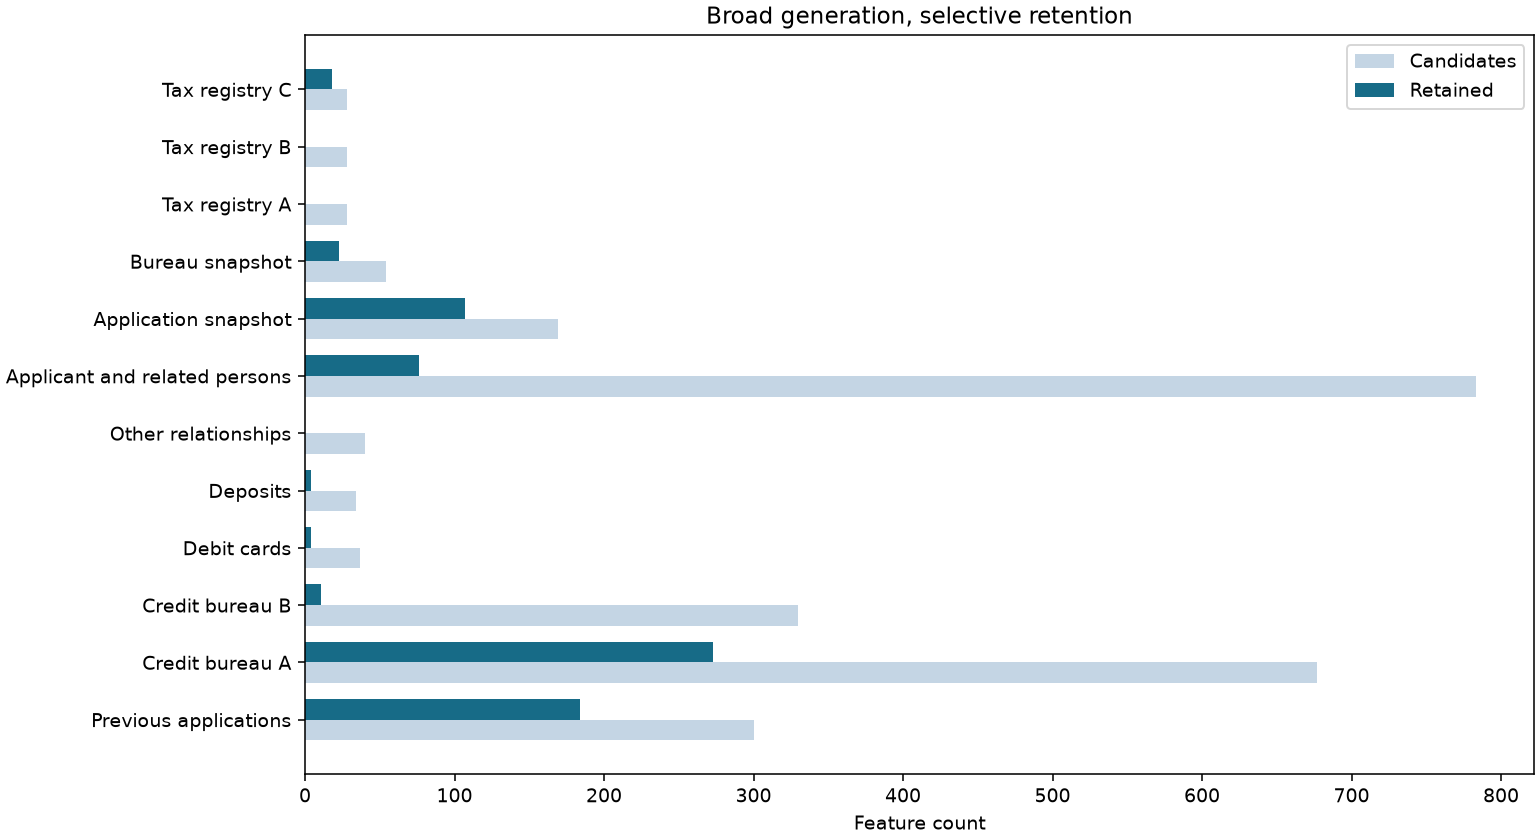

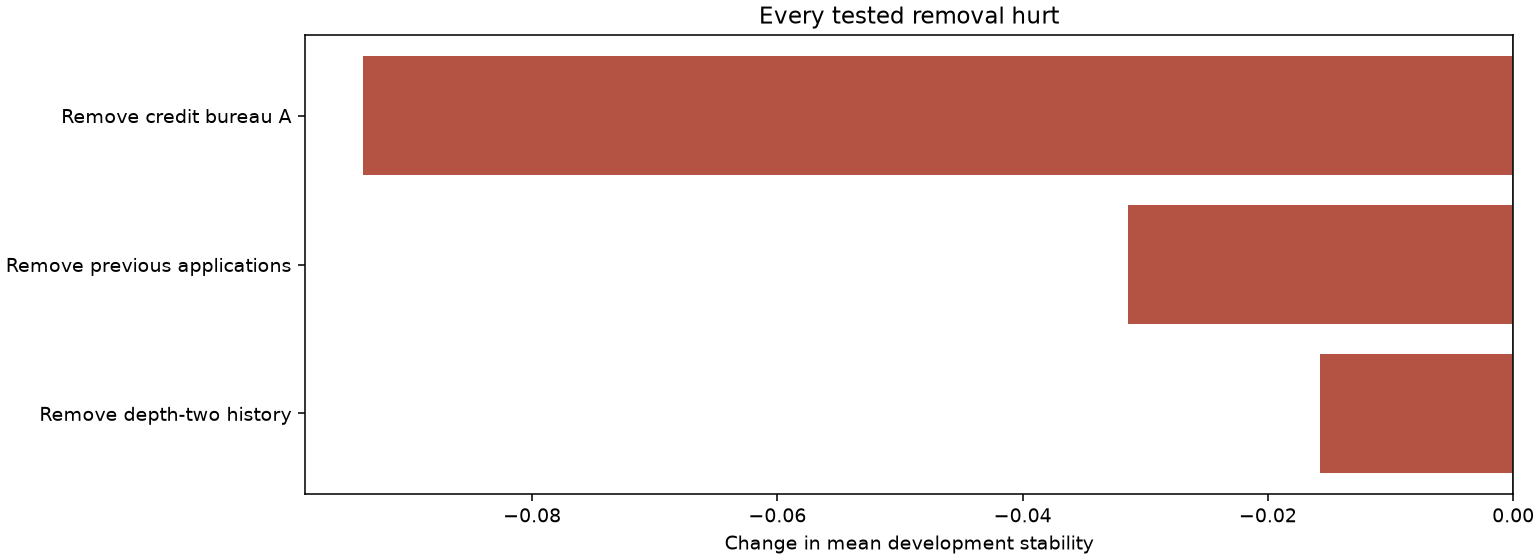

In [2]:
from home_credit.modeling.portfolio_report import display_charts

display(pd.DataFrame(features["families"]).fillna(0).set_index("family"))
display_charts(evidence, "features")

## Training-only selection and its limits

Screening fits on weeks 0-24, uses weeks 25-32 for early stopping and temporal
drift diagnostics, and finishes before the five model-validation folds begin
at week 33. It rejects extreme missingness, constants and high-cardinality
categoricals, then ranks training-window predictive gain with a drift penalty.

The 1,334 eligible features below the 700-feature limit are **not proven useless**.
The limit is a computation budget. The later study in notebook 11 directly tests
1,400 original features: a small mean gain accompanies a weaker worst fold.
The near-perfect early-versus-later drift classifier makes temporal testing essential.
Feature gain is associative and is not a causal explanation or a substitute for ablation.

In [3]:
catalog = pd.DataFrame(features["catalog"])
columns = ["name", "family", "target_gain", "drift_gain", "selection_score", "decision"]
ranked = catalog[catalog["selected"]].sort_values("selection_score", ascending=False)
display(ranked[columns].head(15))
print("Temporal drift-classifier AUC:", round(features["drift_validation_auc"], 6))

,name,family,target_gain,drift_gain,selection_score,decision
2214,static__d0__avgdpdtolclosure24_3658938P,static,9477.527555,0.407763,1.000000,retained
939,credit_bureau_a__d2__pmts_overdue_1140A__mean,credit_bureau_a,3989.947948,0.000000,0.420990,retained
1477,person__d1__all__empl_employedfrom_271D__first,person,3441.521535,26072.415759,0.360954,retained
2354,static__d0__pmtnum_254L,static,3287.267658,2534.517919,0.346647,retained
2415,static_cb__d0__pmtssum_45A,static_cb,3269.330953,1267.868909,0.344856,retained
460,credit_bureau_a__d1__dpdmaxdateyear_596T__mean,credit_bureau_a,3259.617151,0.000000,0.343931,retained
2381,static_cb__d0__days90_310L,static_cb,2596.149539,0.000000,0.273927,retained
2377,static_cb__d0__days120_123L,static_cb,2555.088600,0.000000,0.269594,retained
1423,person__d1__all__birth_259D__first,person,2265.001992,1302.418854,0.238915,retained
216,applprev__d1__maxdpdtolerance_577P__mean,applprev,2204.639210,0.000000,0.232618,retained


Temporal drift-classifier AUC: 0.998944


## What the ablations establish

Under the same LightGBM control and five expanding folds, removing credit bureau A,
previous applications or depth-two history reduced mean official stability.
This supports retaining those families in this representation. It does not prove
that every individual retained column helps, or that all possible feature families
have been exhausted. The detailed executed ablation is notebook 06.

In [4]:
display(
    pd.DataFrame(evidence["ablation"]["rows"])[
        ["experiment", "mean_fold_stability", "delta_vs_control", "worst_fold_stability", "oof_auc"]
    ].round(6)
)

,experiment,mean_fold_stability,delta_vs_control,worst_fold_stability,oof_auc
0,control,0.585188,0.000000,0.393682,0.846894
1,without_depth2,0.569426,-0.015762,0.355247,0.846051
2,without_previous_applications,0.553748,-0.031440,0.292277,0.845742
3,without_credit_bureau_a,0.491375,-0.093813,0.375419,0.821066


## Explicit research boundary

[Notebook 11](11_feature_research.ipynb) completes a separate post-release study:
4,617 additional hypotheses, 256 retained additions, 20 comparison fits and
five-fold SHAP, grouped permutation and redundancy diagnostics. It tests ratios,
dispersion, category interactions, peer statistics and the original feature cap.
Better pooled metrics did not translate into better temporal stability, so the
frozen release remains unchanged. The observed holdout was not reused.

Notebook 11 also contains a separately registered raw-history study: within-applicant
medians, interquartile ranges, upper-tail quantiles and skew, tested against the same
control and with a skew-removal ablation. Its catalog, five-fold comparison and
independent native-model replay retain their own identities.

The raw schema audit excludes chronological trends without verified event and
availability semantics. Peer quantiles describe training populations. CatBoost's native
target statistics were evaluated in the original model benchmark; online
default-rate histories would require outcome-availability controls. No finite
candidate catalog establishes exhaustive discovery.

The full aggregate feature catalog is `reports/feature_ablation/feature_screen.json`;
each entry records provenance, dtype, missingness, cardinality and both model gains.
Rejection reasons here are reconstructed from that immutable record and its original
rules. The feature/model lineage is checked before any results are displayed.